# Support Vector Machines

This notebook examines the behavior of Support Vector Machine classifiers under different parameter settings, with particular attention to margin geometry and decision boundaries.
The primary tuning parameter is the cost parameter *C*, which controls the tradeoff between margin width and classification error. *C* must be non-negative. Larger values of *C* correspond to narrower margins and a stronger emphasis on minimizing training misclassification.

Kernel functions explored include the linear kernel (`'linear'`), the radial basis function kernel (`'rbf'`), which introduces the additional hyperparameter *$\gamma$*, and the polynomial kernel (`'poly'`), which introduces the degree parameter.

This study focuses on the bias–variance tradeoff associated with varying *C* and *$\gamma$*, examined visually through changes in decision boundaries. 

In [1]:
from sklearn import svm

example = svm.SVC(
    C=1.0, # Regularization parameter
    kernel='rbf', # Kernel type: 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
    degree=3, # Degree for 'poly' kernel
    gamma='scale', # Kernel coefficient for 'rbf' options: 'scale', 'auto', or a float value
    coef0=0.0, # Independent term in kernel function for 'poly' and 'sigmoid'
    shrinking=True, # Whether to use the shrinking heuristic
    probability=False, # Whether to enable probability estimates
    tol=0.001, # Tolerance for stopping criterion
    cache_size=200, # Size of the kernel cache (in MB)
    class_weight=None, # Set the parameter C of class i to class_weight[i]*C for SVC. If not given, all classes are supposed to have weight one.
    verbose=False, # Enable verbose output. Note that this setting takes advantage of a per-process runtime setting in libsvm that, if enabled, may not work properly in a multithreaded context.
    max_iter=-1, # Hard limit on iterations within solver, or -1 for no limit.
    decision_function_shape='ovr', # Whether to return a one-vs-rest ('ovr') decision function of shape (n_samples, n_classes) as all other classifiers, or the original one-vs-one ('ovo') decision function of libsvm which has shape (n_samples, n_classes * (n_classes - 1) / 2). However, note that internally, one-vs-one ('ovo') is always used as multi-class strategy. The parameter will only affect the shape of the returned decision function.
    break_ties=False, # If true, decision_function_shape='ovr', and number of classes > 2, predict will break ties according to the confidence values of decision_function; otherwise the first class among the tied classes is returned.
    random_state=None, # Controls the pseudo random number generation for shuffling the data for probability estimates. Ignored when probability is False.
)

In [2]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

splits = np.load("data/iris_splits.npz", allow_pickle=True)

# Extracting the standardized training and test sets for sepal and petal features, along with the corresponding labels
X_sepal_train_std = splits["X_sepal_train_std"]
X_sepal_test_std  = splits["X_sepal_test_std"]
X_petal_train_std = splits["X_petal_train_std"]
X_petal_test_std  = splits["X_petal_test_std"]
X_train_combined = splits["X_train_combined"]
X_test_combined  = splits["X_test_combined"]
y_train = splits["y_train"]
y_test  = splits["y_test"]

In [3]:
import sys
sys.path.append("src")

# This is a custom utility function for plotting decision regions
from utils import plot_decision_regions

### Petal Classification

In [4]:
# Default kernel='rbf', but linear is more interpretable for this dataset, options are 'linear', 'poly', 'rbf', 'sigmoid'
# Default C=1.0 for cost parameter, smaller C values create wider margins but allow more misclassifications, 
# while larger C values create narrower margins and fewer misclassifications but overfit the training data
model = svm.SVC(kernel='linear') 
model.fit(X_petal_train_std, y_train)
y_pred = model.predict(X_petal_test_std)
print("Petal Linear SVM C = 1.0")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Petal Linear SVM C = 1.0
Test Accuracy: 0.9333333333333333
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [5]:
def svm_parameter_grid_plot(
    X, y, param_values, kernel='rbf', param_name='gamma',
    C=1.0, figsize=(20, 10)
):
    """Plots decision boundaries for SVM with varying parameters."""

    plt.figure(figsize=figsize)

    for i, val in enumerate(param_values, 1):

        if param_name == "C":
            model = svm.SVC(kernel=kernel, C=val)
        else:
            model = svm.SVC(kernel=kernel, C=C, **{param_name: val})

        model.fit(X, y)

        plt.subplot(2, 3, i)

        plot_decision_regions(
            X, y,
            classifier=model,
            title=f"{kernel.upper()} SVM ({param_name}={val})"
        )

        # Plot support vectors
        sv = model.support_vectors_
        plt.scatter(
            sv[:, 0], sv[:, 1],
            s=100,
            facecolors='none',
            edgecolors='k',
            marker='X',
            linewidth=1.5
        )

    plt.tight_layout()
    plt.show()

### Linear Kernel

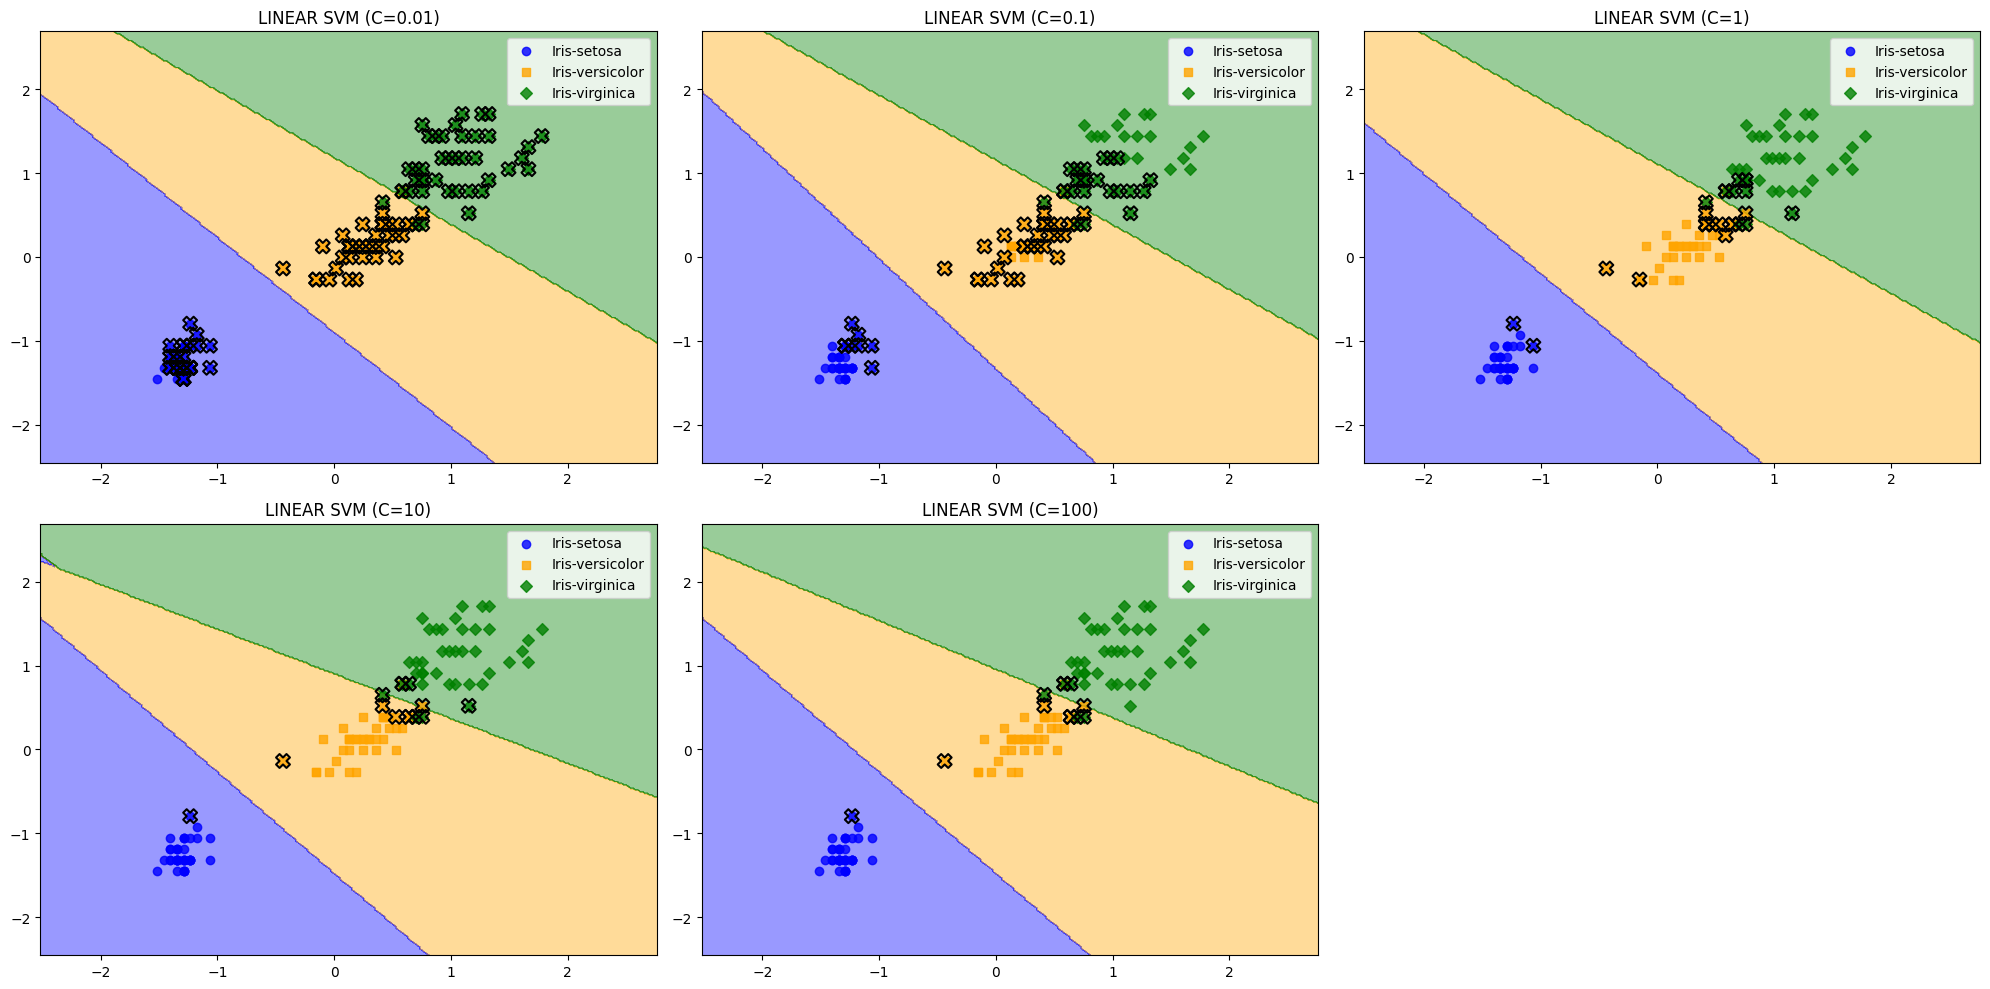

In [6]:
grid = [0.01, 0.1, 1, 10, 100]

svm_parameter_grid_plot(
    X_petal_train_std, y_train, param_values=grid, kernel='linear', param_name='C'
)

Across the range of tested *C* values, the decision boundaries in the petal feature space remain largely unchanged. The margin geometry appears stable, with minimal visible shifts in the separating hyperplanes. The primary difference observed is in the number of support vectors rather than the orientation or placement of the boundary itself. As *C* increases, the margin becomes narrower, resulting in fewer support vectors.

Given the strong separability of the petal features, increasing *C* does not substantially alter the classification regions. For this feature subset, the default value *C = 1* appears sufficient without introducing additional complexity.

### Radial Kernel

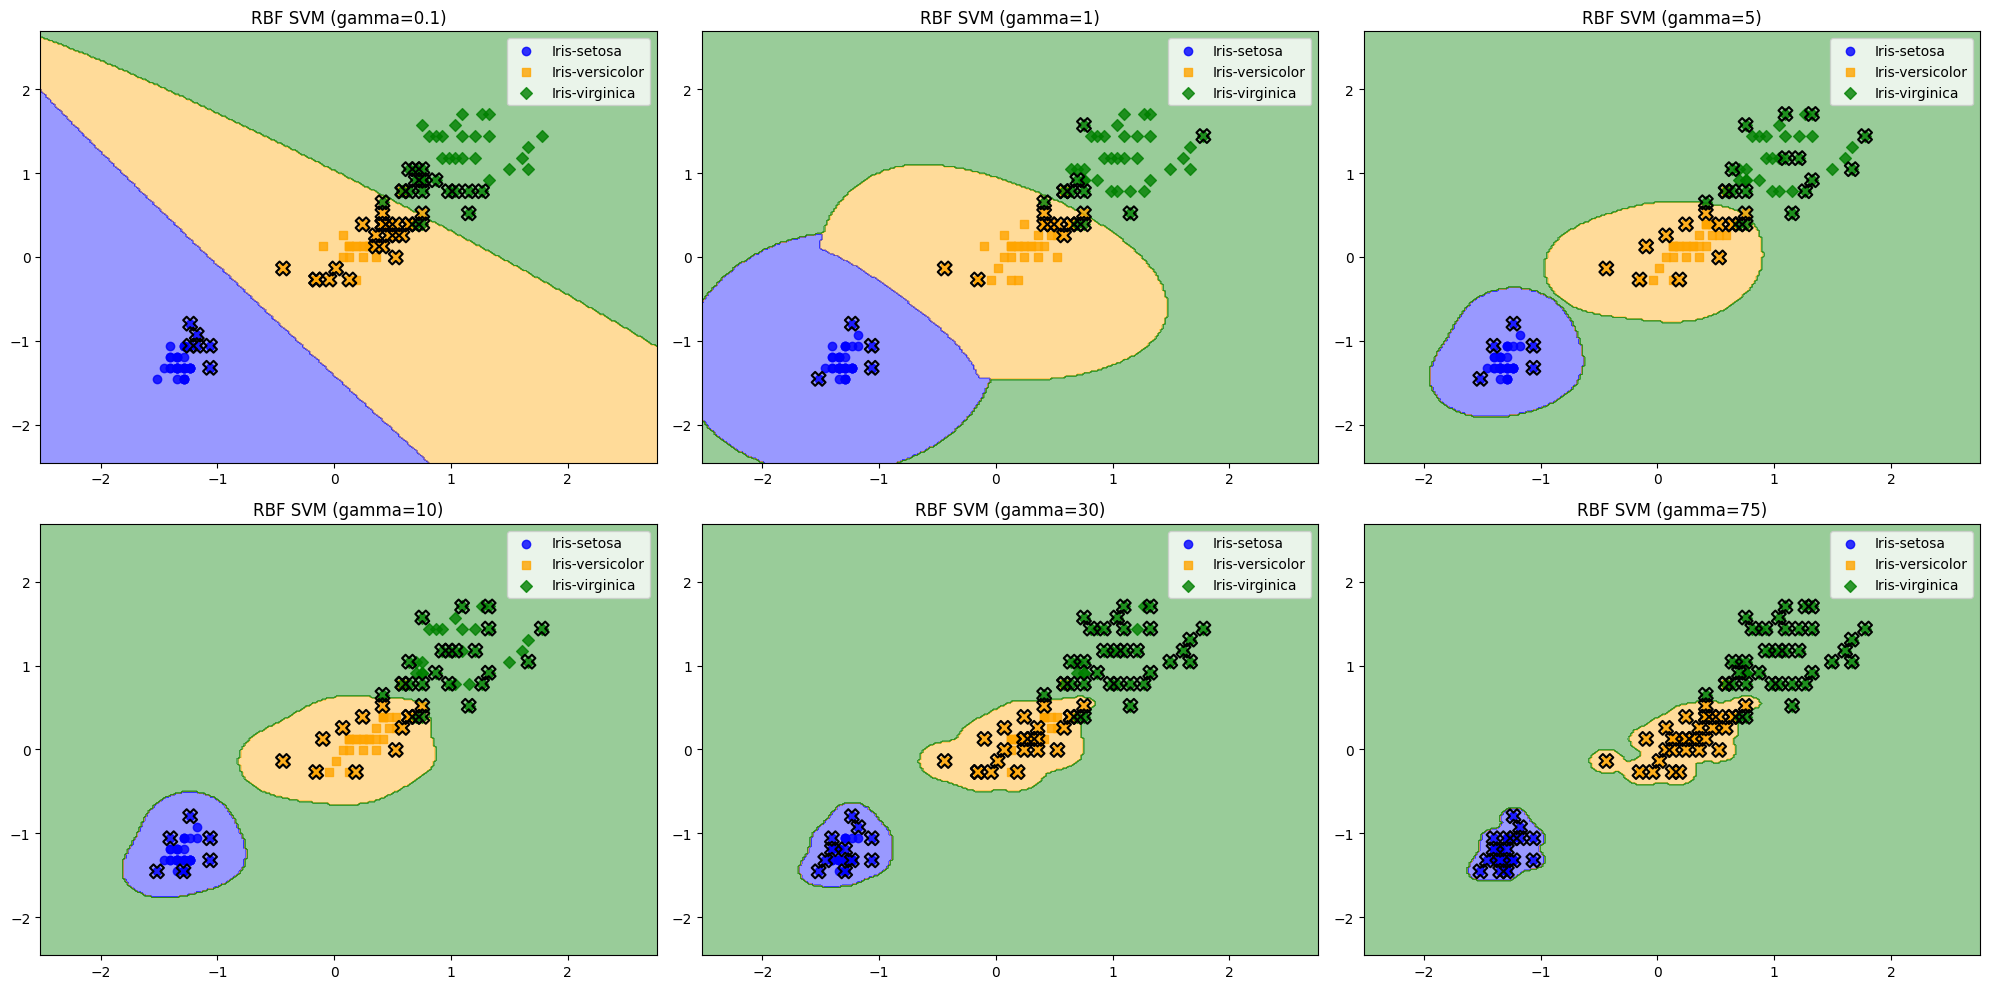

In [7]:
# Gamma values options are 'scale' (default) and 'auto', but we will specify numeric values to see the effect on decision boundaries
gamma_values = [0.1, 1, 5, 10, 30, 75]
# Plot decision boundaries for each gamma value
svm_parameter_grid_plot(
    X_petal_train_std, y_train, param_values=gamma_values, kernel='rbf', param_name='gamma', C=1.0
)

Across the tested values of $\gamma$, increasing $\gamma$ results in increasingly complex decision boundaries. Smaller values of $\gamma$ produce smoother, more linear-like boundaries, while larger values introduce more localized curvature. As $\gamma$ increases, the model becomes more sensitive to individual observations, leading to overfitting.

Because the petal features are already close to linearly separable, this added complexity is unnecessary for accurate classification. However, varying $\gamma$ provides a clear demonstration of how the RBF kernel controls model flexibility and boundary shape.

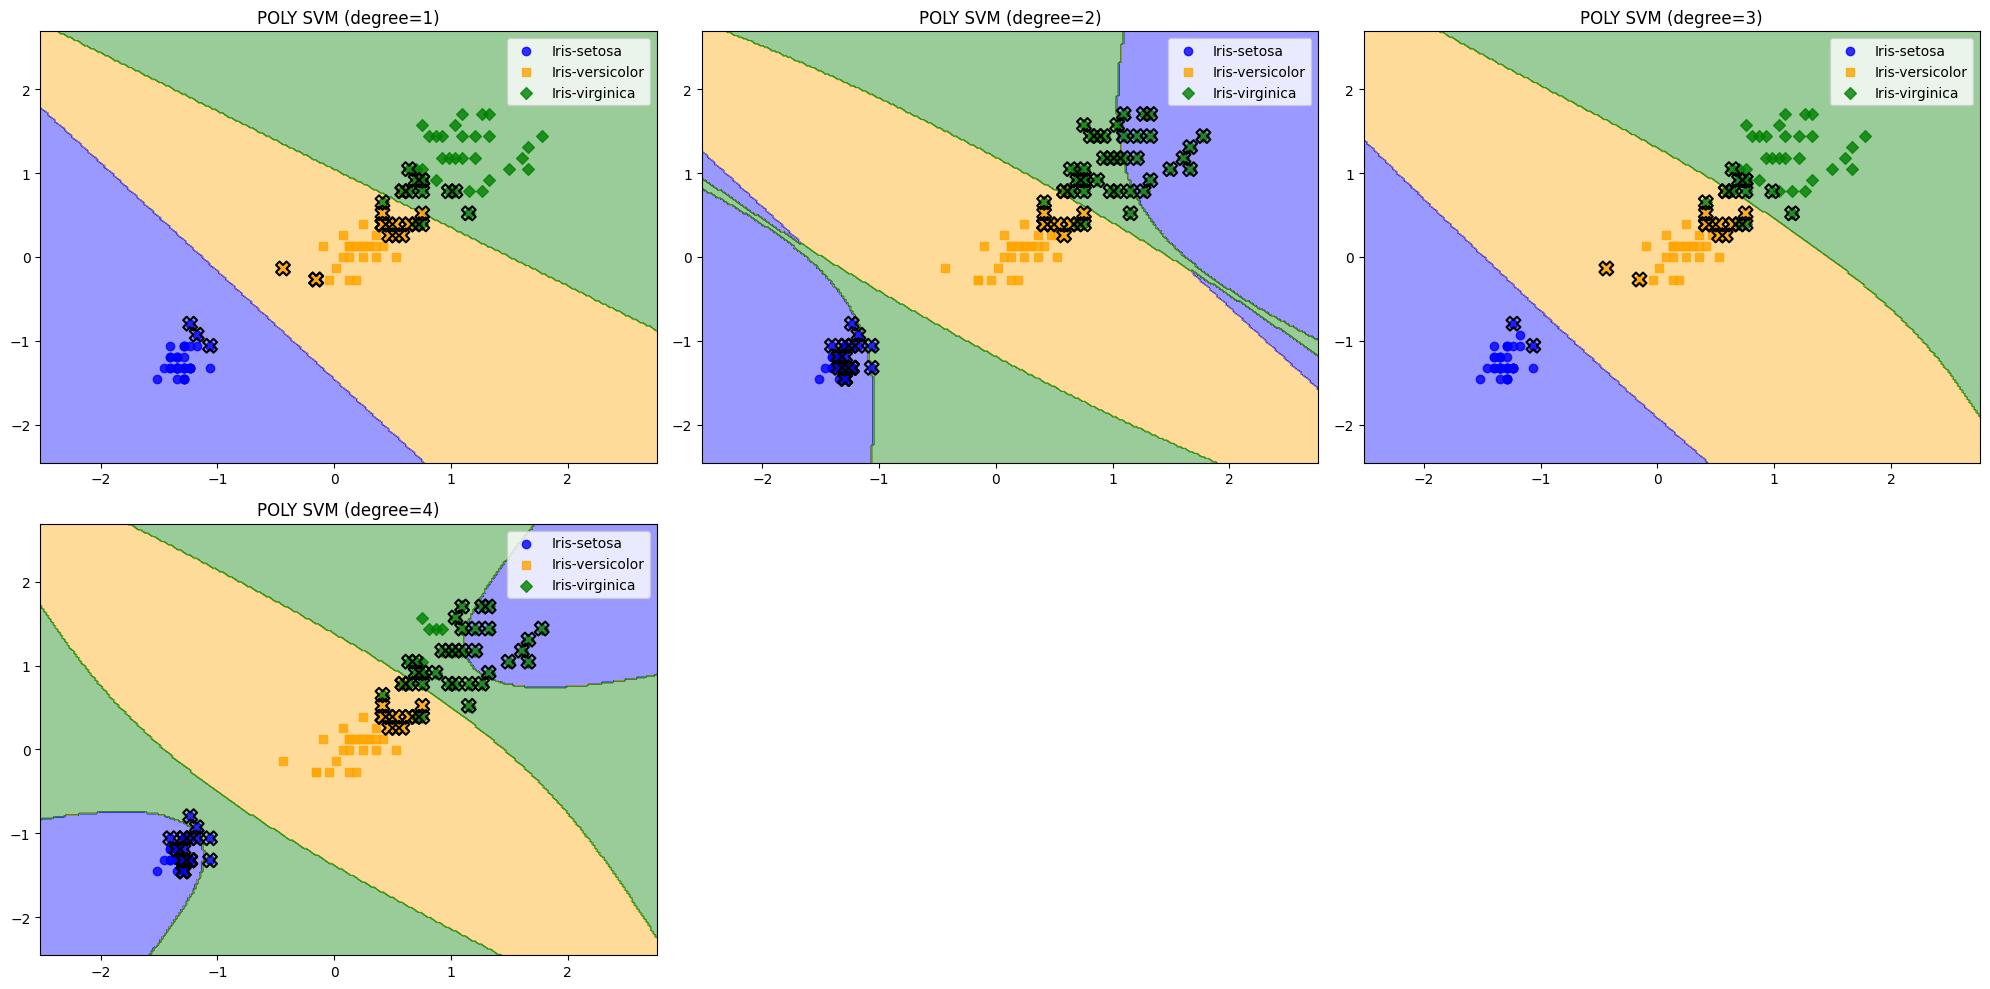

In [8]:
degree_grid = [1, 2, 3, 4]
# Plot decision boundaries for each degree value
svm_parameter_grid_plot(
    X_petal_train_std, y_train, param_values=degree_grid, kernel='poly', param_name='degree', C=1.0
)

Across the tested polynomial degrees, increasing the degree results in increasingly complex decision boundaries. Odd degrees produce boundaries that are closer to linear, while even degrees introduce greater curvature and localized adjustments to the data.

Similar to the RBF kernel, this additional complexity is unnecessary for the petal feature space, which is already close to linearly separable. Higher polynomial degrees therefore increase model flexibility without providing meaningful improvement in separation, illustrating how excessive model capacity can introduce unnecessary complexity.

### Sepal Classification

In [9]:
model = svm.SVC(kernel='linear') # define the SVM model with a linear kernel cost = 1
model.fit(X_sepal_train_std, y_train)
y_pred = model.predict(X_sepal_test_std)
print("Sepal Linear SVM C = 1.0")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Sepal Linear SVM C = 1.0
Test Accuracy: 0.7333333333333333
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.62      0.50      0.56        10
 Iris-virginica       0.58      0.70      0.64        10

       accuracy                           0.73        30
      macro avg       0.74      0.73      0.73        30
   weighted avg       0.74      0.73      0.73        30

Confusion Matrix:
 [[10  0  0]
 [ 0  5  5]
 [ 0  3  7]]


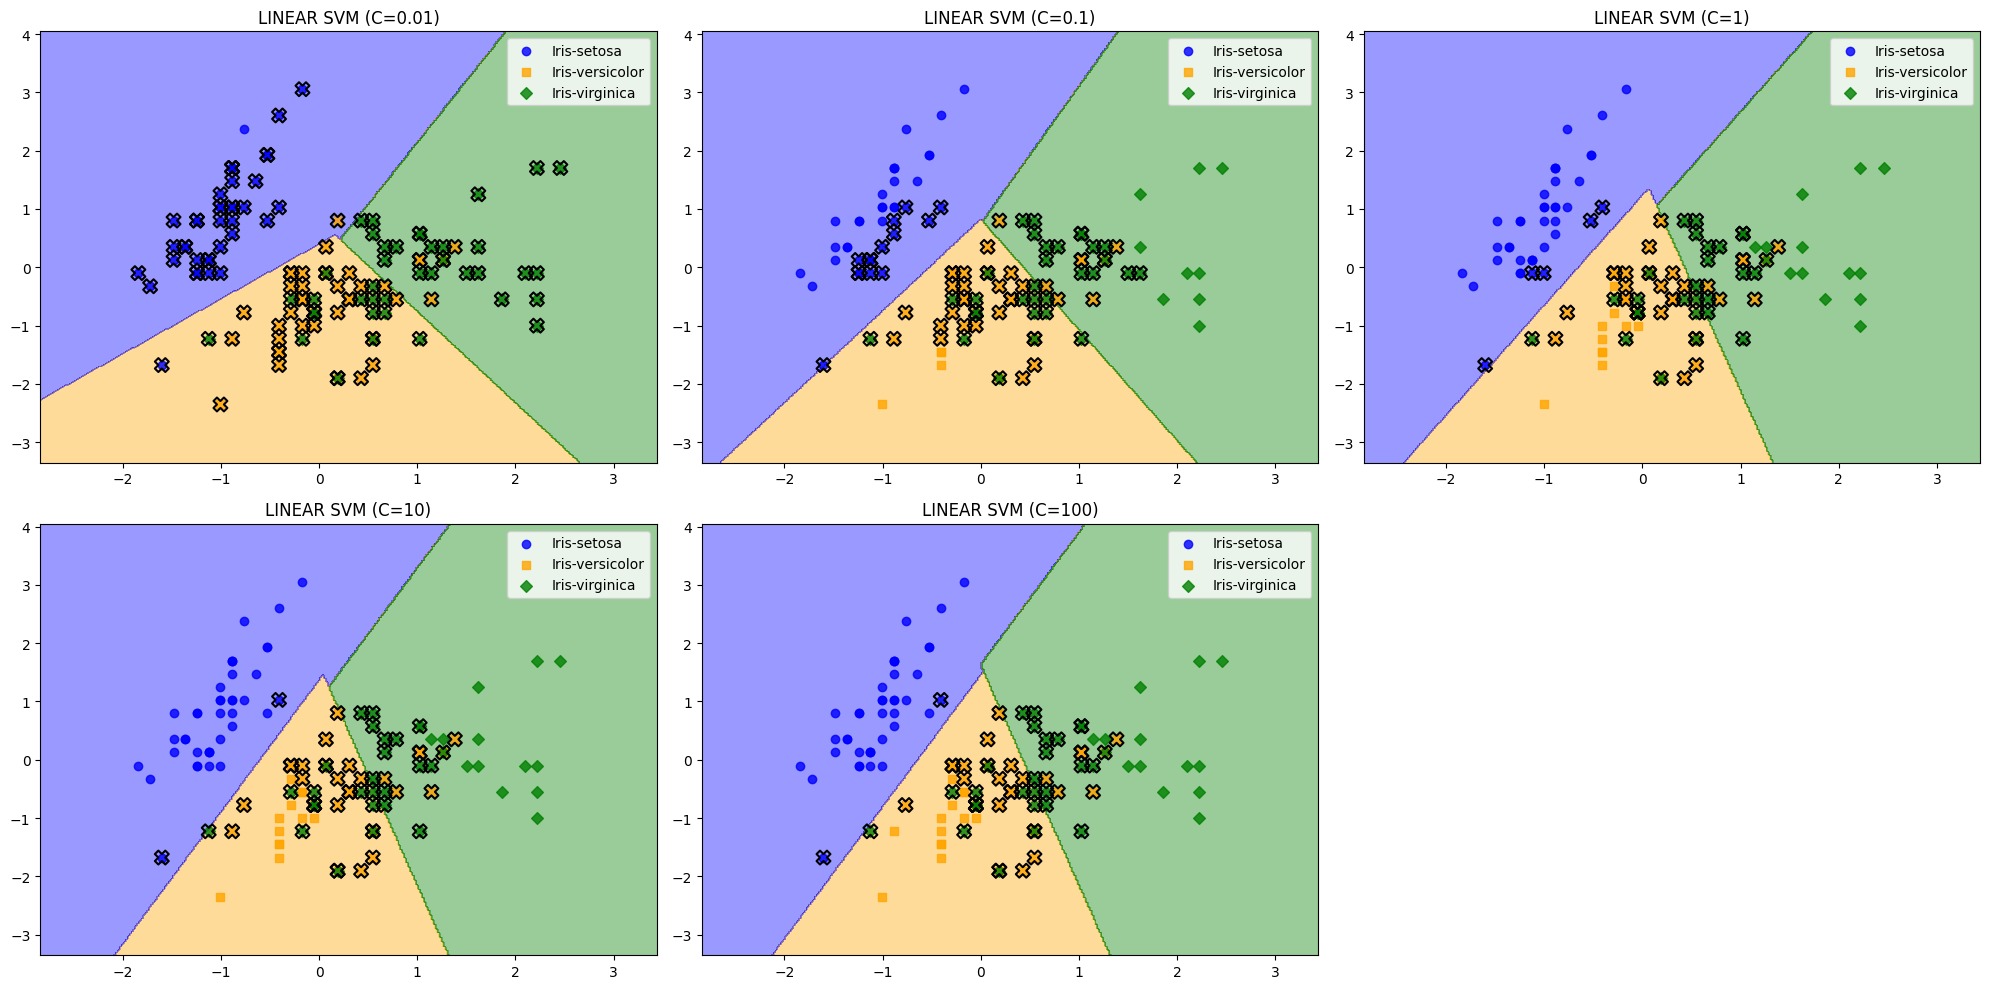

In [10]:
svm_parameter_grid_plot(
    X_sepal_train_std, y_train, param_values=grid, kernel='linear', param_name='C'
)

Across the tested values of *C*, increasing *C* results in narrower margins and a stronger penalty for misclassification. In the sepal feature space, Versicolor and Virginica overlap, making perfect linear separation impossible. As a result, misclassifications are unavoidable under a linear model.

While the number of Setosa support vectors decreases as *C* increases due to its clearer separability, the overlapping classes retain a relatively high number of support vectors. The decision boundary shifts more noticeably between the overlapping classes as *C* increases, reflecting the model’s attempt to reduce training error. However, increasing *C* in a non-linearly separable setting does not guarantee improved generalization and may instead increase sensitivity to overlapping observations.

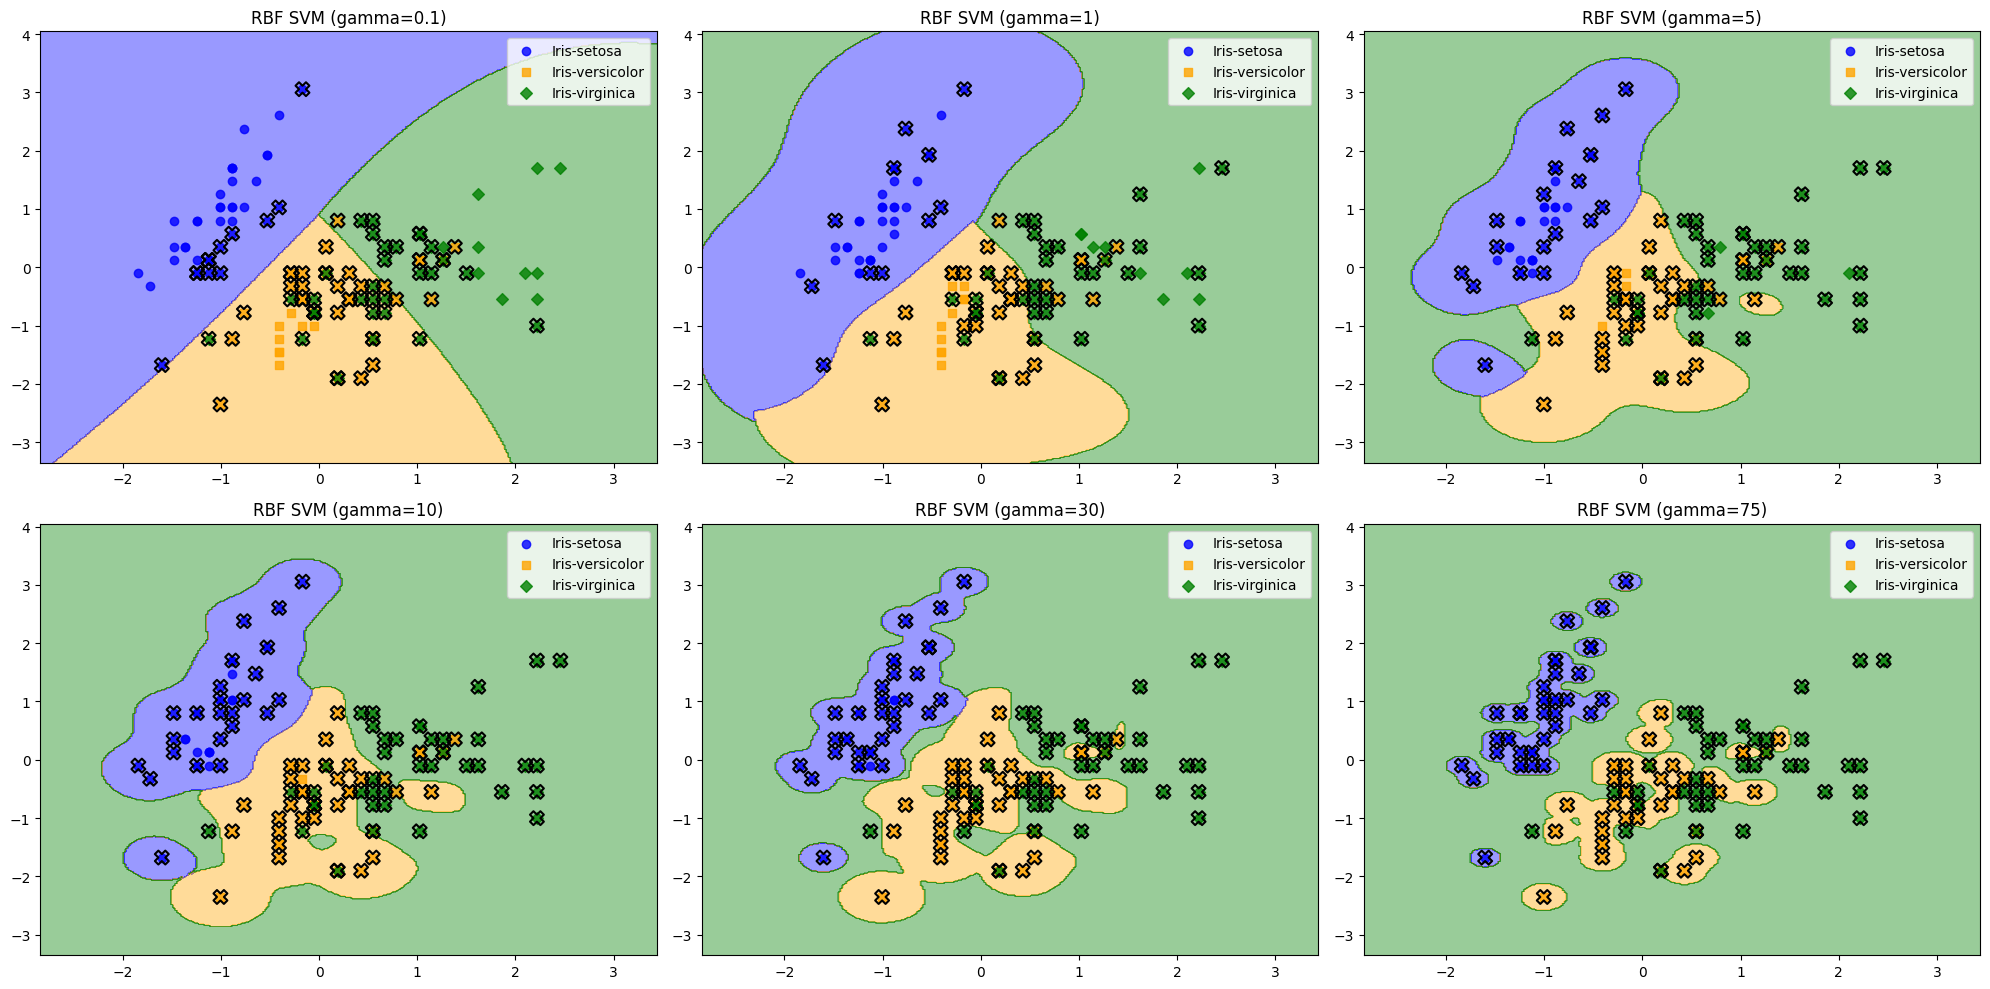

In [11]:
svm_parameter_grid_plot(
    X_sepal_train_std, y_train, param_values=gamma_values, kernel='rbf', param_name='gamma', C=1.0
)

Across the tested values of $\gamma$ in the sepal feature space, increasing $\gamma$ results in increasingly complex and localized decision boundaries. As $\gamma$ becomes larger, the model forms small “islands” around clusters of training observations. This behavior reflects the model’s increasing sensitivity to individual data points.

Because the sepal features exhibit class overlap, this added flexibility does not resolve separability but instead leads to overfitting. The highly irregular boundaries indicate that the model is adapting closely to the training data rather than capturing a broader underlying structure.

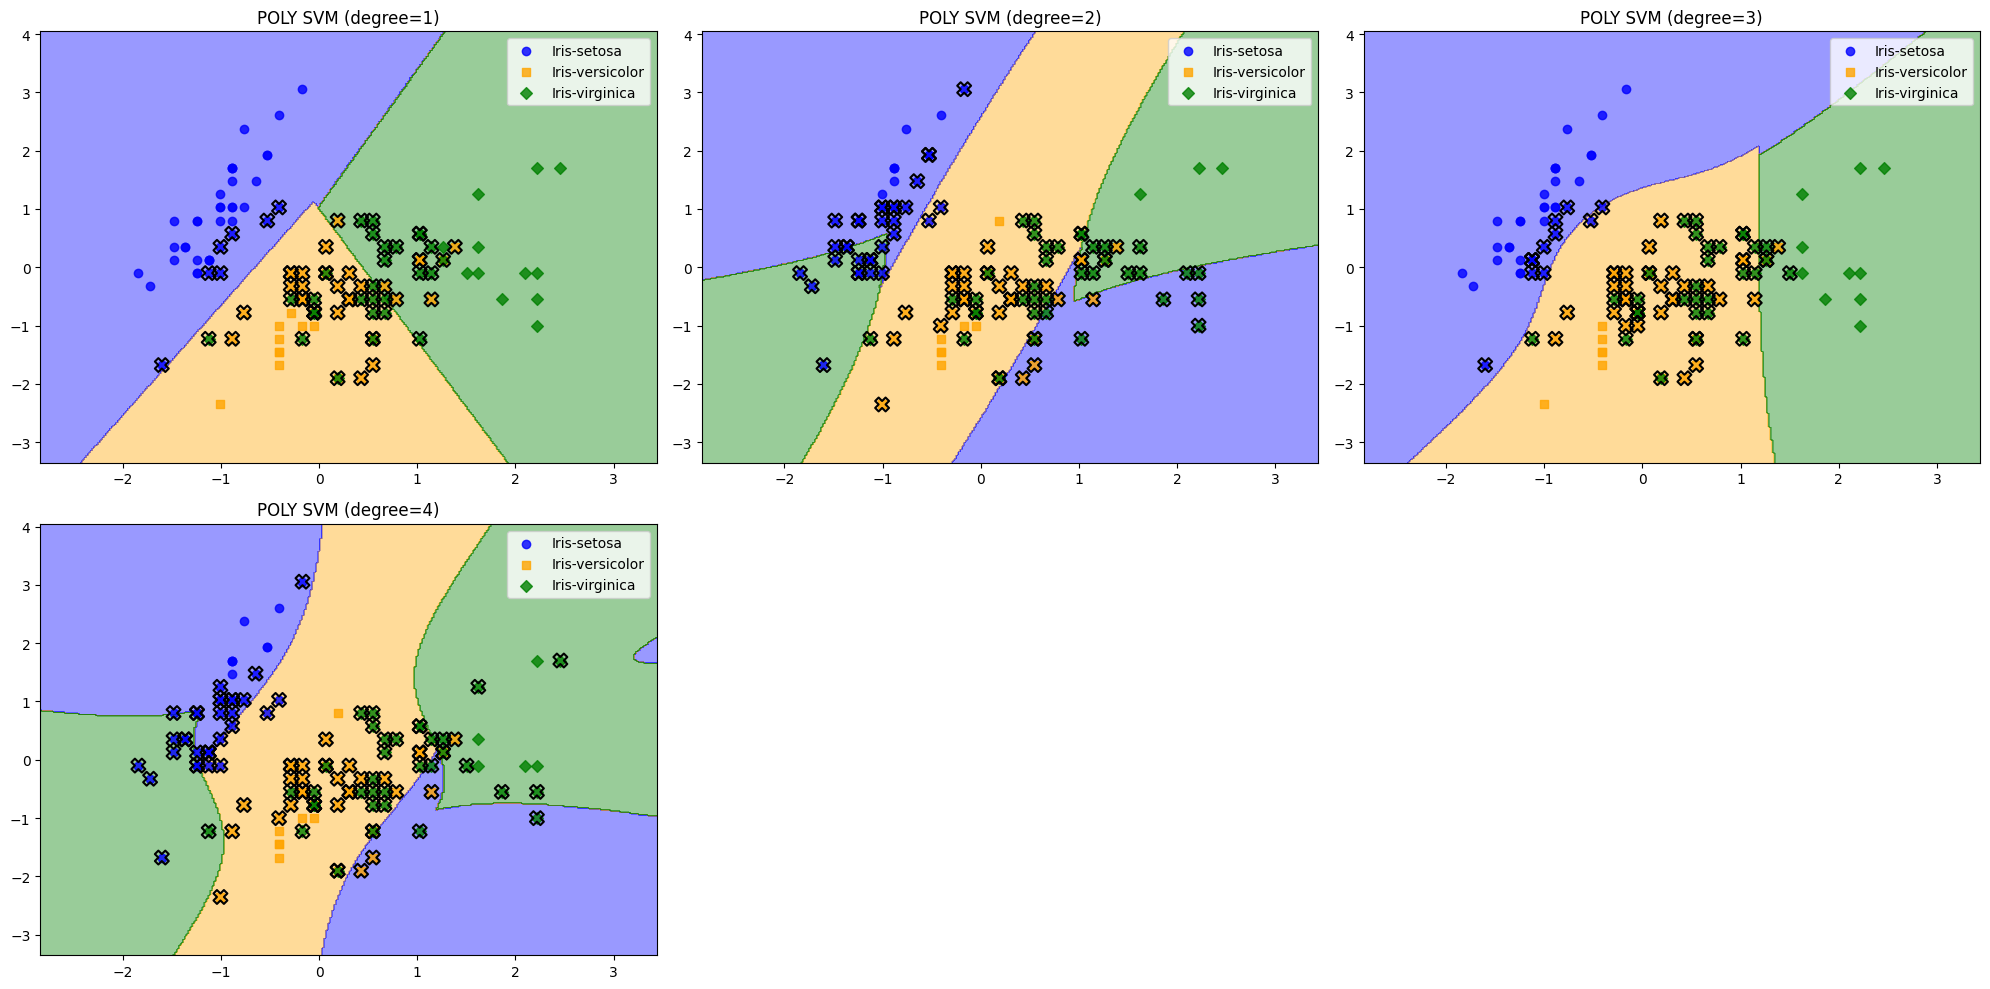

In [12]:
svm_parameter_grid_plot(
    X_sepal_train_std, y_train, param_values=degree_grid, kernel='poly', param_name='degree', C=1.0
)

Degree one corresponds to a linear decision boundary, increasing the polynomial degree introduces curvature into the boundary; however, this added flexibility does not meaningfully improve class separation.

Because Versicolor and Virginica overlap in the sepal features, increasing the polynomial degree does not resolve the underlying non-separability. Instead, higher degrees introduce additional complexity without producing clearer class boundaries, indicating that polynomial expansion does not substantially improve separation in this feature space.

### Combined Classification

In [13]:
model = svm.SVC(kernel='linear', C=1.0, probability=True) # define the SVM model with a linear kernel and cost = 1, enable probability estimates for ROC curve
model.fit(X_train_combined, y_train)
y_pred = model.predict(X_test_combined)
print("Combined Sepal + Petal Linear SVM C = 1.0")
print("Accuracy:", accuracy_score(y_test, y_pred))


Combined Sepal + Petal Linear SVM C = 1.0
Accuracy: 1.0


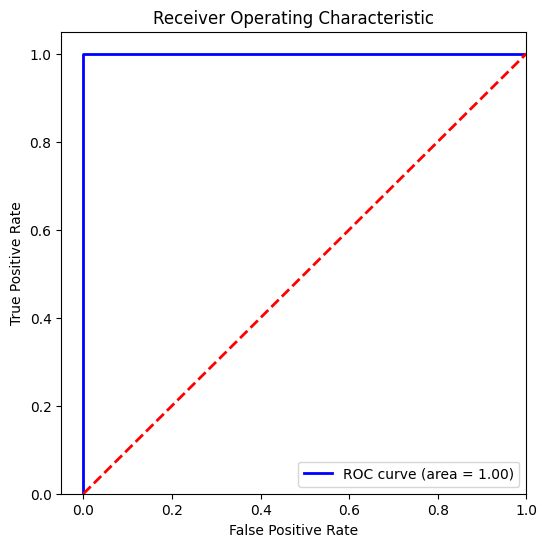

In [14]:
y_test_bin = label_binarize(y_test, classes=model.classes_)

# Choose class index (e.g., class 1)
class_index = 1
y_score = model.predict_proba(X_test_combined)[:, class_index]

fpr, tpr, thresholds = roc_curve(
    y_test_bin[:, class_index],  # choose class index
    y_score
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])   
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Conclusion

Individually, the sepal and petal feature subsets are not fully separable under a linear SVM. Using only petal features resulted in approximately 93% test accuracy, while using only sepal features resulted in approximately 73% accuracy due to class overlap. In contrast, combining all four features in a linear SVM with *C=1* produced 100% accuracy on the test set.

These results highlight the importance of feature representation in classification performance. While model complexity and kernel choice influence decision boundary geometry, the separability of the underlying feature space plays a dominant role.

From this study, key practical takeaways for future projects include understanding the role of the cost parameter *C* in controlling margin width and misclassification penalties, and the role of $\gamma$ in the RBF kernel in controlling model flexibility. Careful tuning of these parameters is essential to balance bias and variance, particularly when classes are not linearly separable.